# 🐍 Python Level 2 - Intermediate course
## Class 2 — Comprehensions and Built-in Functions
### 📝 Practice Exercises — Solutions

**Python instructor - Luis Dias**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">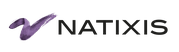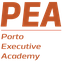</div>

---

---

| Section | Difficulty | Topics |
|---------|------------|--------|
| A | 🟢 Warm-up | list comprehensions |
| B | 🟡 Core practice | dict and set comprehensions, `lambda` |
| C | 🟠 Applied | `sorted` with a key, `map`, `filter` |
| D | 🔴 Challenge | `zip`, `any`, `all`, and a full summary |

> 💡 These are **one** correct answer each. A `for` loop that gives the same result is not
> wrong but the point today is to practise saying it in one line.

---

## ⚙️ Setup

In [ ]:
numbers = [4, 11, 7, 22, 9, 30, 2]

cities = [
    {"name": "Porto",    "population": 231962, "country": "Portugal", "coastal": True},
    {"name": "Lisbon",   "population": 545923, "country": "Portugal", "coastal": True},
    {"name": "Madrid",   "population": 3223334, "country": "Spain",   "coastal": False},
    {"name": "Seville",  "population": 684025, "country": "Spain",    "coastal": False},
    {"name": "Bordeaux", "population": 257068, "country": "France",   "coastal": False},
]

print("Setup complete:", len(numbers), "numbers and", len(cities), "cities")

---
## 🟢 Section A — Warm-up

> 🕐 Estimated time: 15 min

### Exercise A1 — Your first comprehension

In [ ]:
# A1 - "what to keep" is the item itself, times 2
doubled = [number * 2 for number in numbers]
print(doubled)

### Exercise A2 — A comprehension with a condition

In [ ]:
# A2 - the "if" goes at the end and decides what gets in
big = [number for number in numbers if number > 10]
print(big)

even = [number for number in numbers if number % 2 == 0]
print(even)

### Exercise A3 — Transform and filter at once

In [ ]:
# A3 - the calculation is at the front, the test at the back
squares_of_small = [number ** 2 for number in numbers if number < 10]
print(squares_of_small)

### Exercise A4 — One field out of a list of dicts

In [ ]:
# A4 - the single most common comprehension there is
names = [city["name"] for city in cities]
print(names)

coastal_names = [city["name"] for city in cities if city["coastal"]]
print(coastal_names)

---
## 🟡 Section B — Core practice

> 🕐 Estimated time: 25 min

### Exercise B1 — A dict comprehension

In [ ]:
# B1 - curly brackets and a colon: key on the left, value on the right
populations = {city["name"]: city["population"] for city in cities}
print(populations)
print(populations["Madrid"])

### Exercise B2 — A dict comprehension with a condition

In [ ]:
# B2 - the condition works exactly as in a list comprehension
portuguese = {c["name"]: c["population"] for c in cities if c["country"] == "Portugal"}
print(portuguese)

### Exercise B3 — A set comprehension

In [ ]:
# B3 - curly brackets with no colon, and duplicates disappear.
# sorted() gives a predictable order to print, since a set has none.
countries = {city["country"] for city in cities}
print(sorted(countries))
print(len(countries))

### Exercise B4 — Lambdas

In [ ]:
# B4 - one expression, no return keyword; the expression IS the result
triple = lambda x: x * 3
print(triple(7))

area = lambda width, height: width * height
print(area(3, 4))

is_big = lambda number: number > 10
print(is_big(22), is_big(4))

---
## 🟠 Section C — Applied

> 🕐 Estimated time: 25 min

### Exercise C1 — Sorting with a key

In [ ]:
# C1 - key says what to sort ON; the list itself is left alone
by_population = sorted(cities, key=lambda city: city["population"])
print([city["name"] for city in by_population])

by_name = sorted(cities, key=lambda city: city["name"])
print([city["name"] for city in by_name])

### Exercise C2 — Sorting the other way, and taking the top few

In [ ]:
# C2 - reverse=True, then a slice takes the first two
biggest = sorted(cities, key=lambda city: city["population"], reverse=True)[:2]
print([city["name"] for city in biggest])

print(sorted(numbers, reverse=True))
print(numbers)              # untouched: sorted() returns a new list

### Exercise C3 — `map` and `filter`

In [ ]:
# C3 - both need list() around them to become a printable list
print(list(map(lambda number: number * 10, numbers)))
print(list(filter(lambda number: number > 10, numbers)))

# The same two jobs as one comprehension - usually easier to read
print([number * 10 for number in numbers if number > 10])

### Exercise C4 — Population in thousands

In [ ]:
# C4 - a dict comprehension doing a calculation on the value
in_thousands = {c["name"]: round(c["population"] / 1000) for c in cities}
print(in_thousands)

---
## 🔴 Section D — Challenge

> 🕐 Estimated time: 25 min

### Exercise D1 — `zip`, `any` and `all`

In [ ]:
# D1 - zip walks two lists together; any/all read a list of True/False
names = [city["name"] for city in cities]
populations = [city["population"] for city in cities]

for name, population in zip(names, populations):
    print(f"{name:<10}{population:>9,}")

print()
coastal_flags = [city["coastal"] for city in cities]
print(coastal_flags)
print("Any coastal?", any(coastal_flags))
print("All coastal?", all(coastal_flags))
print("Any over 1m?", any(population > 1000000 for population in populations))
print("All over 100k?", all(population > 100000 for population in populations))

### Exercise D2 — City report

In [ ]:
# D2 - every tool from the class, one after another
POPULATION_LIMIT = 500000

# Three comprehensions, three sets of brackets
large_names = [city["name"] for city in cities if city["population"] > POPULATION_LIMIT]
lookup = {city["name"]: city["population"] for city in cities}
countries = {city["country"] for city in cities}

# Sorting by something derived from each item
by_population = sorted(cities, key=lambda city: city["population"], reverse=True)
top_two = [city["name"] for city in by_population[:2]]

# Totals from a comprehension of the populations
populations = [city["population"] for city in cities]
total = sum(populations)
average = round(total / len(populations))

# The table: two separate lists, walked together
names = [city["name"] for city in by_population]
sorted_populations = [lookup[name] for name in names]

print("CITY REPORT (largest first)")
print("-" * 30)
for name, population in zip(names, sorted_populations):
    print(f"{name:<10}{population:>10,}")

print("-" * 30)
print(f"Cities        : {len(cities)}")
print(f"Countries     : {sorted(countries)}")
print(f"Over 500k     : {large_names}")
print(f"Top two       : {top_two}")
print(f"Total         : {total:,}")
print(f"Average       : {average:,}")
print(f"All coastal?  : {all(city['coastal'] for city in cities)}")
print(f"Any in France?: {any(city['country'] == 'France' for city in cities)}")

---

### 🎉 Well done!

| | Concept | Exercises |
|-|---------|----------|
| ✅ | List comprehension | A1, A4 |
| ✅ | …with a condition | A2, A4 |
| ✅ | …transform and filter | A3 |
| ✅ | Dict comprehension | B1, B2, C4 |
| ✅ | Set comprehension | B3 |
| ✅ | `lambda` | B4, C1, C2, C3 |
| ✅ | `sorted` with `key` | C1, C2 |
| ✅ | `reverse=True` and slicing | C2 |
| ✅ | `map` and `filter` | C3 |
| ✅ | `zip` | D1, D2 |
| ✅ | `any` and `all` | D1, D2 |

**The judgement to take away:** every comprehension here replaced four lines with one *and* was
easier to read. When that stops being true two `for`s, a condition you have to squint at then
write the loop. Clever is not the goal but instead writing clear code that others can understand.